In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "N": 2**26,
        "dx": 3.1e-10,
        "z_detector":2.4,
        "detector_size": 8e-3,
        "detector_pixel_size_x": 8e-6,
        "detector_pixel_size_y": 1,
        "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [8639-25, 8639+25],
        "x_range": [-3e-7, 3e-7],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 0.8,
            "pixel_size_x": 1 * 1e-7,
            "pixel_size_z": 1 * 1e-7,
            "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/double_ring_911_844_803_3d_c1_1e-7.npy",
            "materials": [["C", 3.23],["H", 0.25],["H", 0.44e-3]],
            "x_positions":[0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  67108864


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2025-09-23 14:26:36,871 INFO: Setting up simulation
2025-09-23 14:26:43,592 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2025/09/20250923_142640182774


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [ ]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
for i in range(1):
    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
#for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
#    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

2025-09-23 14:26:43,611 INFO: Running single simulation for source 0 in simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/09/20250923_142640182774
2025-09-23 14:27:03,326 INFO: Applying optical element 1/1 (Sample)


In [ ]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-3e-6, 3e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1])

In [ ]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3dc1_1e7.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

In [ ]:
#以下是历史仿真结果

[-4.000e-03 -3.992e-03 -3.984e-03 -3.976e-03 -3.968e-03 -3.960e-03
 -3.952e-03 -3.944e-03 -3.936e-03 -3.928e-03 -3.920e-03 -3.912e-03
 -3.904e-03 -3.896e-03 -3.888e-03 -3.880e-03 -3.872e-03 -3.864e-03
 -3.856e-03 -3.848e-03 -3.840e-03 -3.832e-03 -3.824e-03 -3.816e-03
 -3.808e-03 -3.800e-03 -3.792e-03 -3.784e-03 -3.776e-03 -3.768e-03
 -3.760e-03 -3.752e-03 -3.744e-03 -3.736e-03 -3.728e-03 -3.720e-03
 -3.712e-03 -3.704e-03 -3.696e-03 -3.688e-03 -3.680e-03 -3.672e-03
 -3.664e-03 -3.656e-03 -3.648e-03 -3.640e-03 -3.632e-03 -3.624e-03
 -3.616e-03 -3.608e-03 -3.600e-03 -3.592e-03 -3.584e-03 -3.576e-03
 -3.568e-03 -3.560e-03 -3.552e-03 -3.544e-03 -3.536e-03 -3.528e-03
 -3.520e-03 -3.512e-03 -3.504e-03 -3.496e-03 -3.488e-03 -3.480e-03
 -3.472e-03 -3.464e-03 -3.456e-03 -3.448e-03 -3.440e-03 -3.432e-03
 -3.424e-03 -3.416e-03 -3.408e-03 -3.400e-03 -3.392e-03 -3.384e-03
 -3.376e-03 -3.368e-03 -3.360e-03 -3.352e-03 -3.344e-03 -3.336e-03
 -3.328e-03 -3.320e-03 -3.312e-03 -3.304e-03 -3.296e-03 -3.288

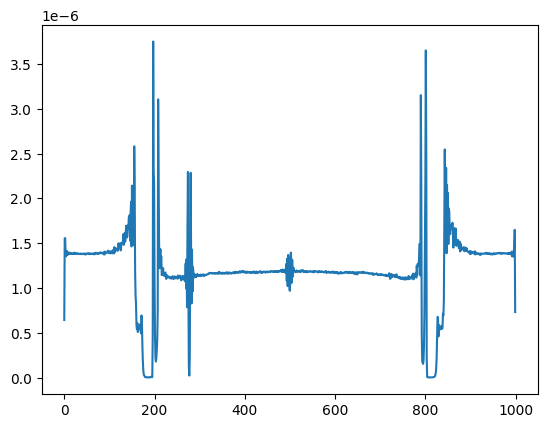

In [9]:
#double_ring_911_844_803_0d_1e-7.npy
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3dc_1e7.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

[-4.000e-03 -3.992e-03 -3.984e-03 -3.976e-03 -3.968e-03 -3.960e-03
 -3.952e-03 -3.944e-03 -3.936e-03 -3.928e-03 -3.920e-03 -3.912e-03
 -3.904e-03 -3.896e-03 -3.888e-03 -3.880e-03 -3.872e-03 -3.864e-03
 -3.856e-03 -3.848e-03 -3.840e-03 -3.832e-03 -3.824e-03 -3.816e-03
 -3.808e-03 -3.800e-03 -3.792e-03 -3.784e-03 -3.776e-03 -3.768e-03
 -3.760e-03 -3.752e-03 -3.744e-03 -3.736e-03 -3.728e-03 -3.720e-03
 -3.712e-03 -3.704e-03 -3.696e-03 -3.688e-03 -3.680e-03 -3.672e-03
 -3.664e-03 -3.656e-03 -3.648e-03 -3.640e-03 -3.632e-03 -3.624e-03
 -3.616e-03 -3.608e-03 -3.600e-03 -3.592e-03 -3.584e-03 -3.576e-03
 -3.568e-03 -3.560e-03 -3.552e-03 -3.544e-03 -3.536e-03 -3.528e-03
 -3.520e-03 -3.512e-03 -3.504e-03 -3.496e-03 -3.488e-03 -3.480e-03
 -3.472e-03 -3.464e-03 -3.456e-03 -3.448e-03 -3.440e-03 -3.432e-03
 -3.424e-03 -3.416e-03 -3.408e-03 -3.400e-03 -3.392e-03 -3.384e-03
 -3.376e-03 -3.368e-03 -3.360e-03 -3.352e-03 -3.344e-03 -3.336e-03
 -3.328e-03 -3.320e-03 -3.312e-03 -3.304e-03 -3.296e-03 -3.288

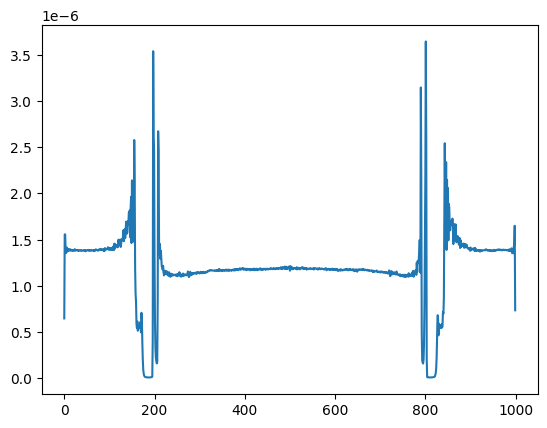

In [12]:
#double_ring_911_844_803_0d_1e-7.npy
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3dc_1e7.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

[-4.000e-03 -3.992e-03 -3.984e-03 -3.976e-03 -3.968e-03 -3.960e-03
 -3.952e-03 -3.944e-03 -3.936e-03 -3.928e-03 -3.920e-03 -3.912e-03
 -3.904e-03 -3.896e-03 -3.888e-03 -3.880e-03 -3.872e-03 -3.864e-03
 -3.856e-03 -3.848e-03 -3.840e-03 -3.832e-03 -3.824e-03 -3.816e-03
 -3.808e-03 -3.800e-03 -3.792e-03 -3.784e-03 -3.776e-03 -3.768e-03
 -3.760e-03 -3.752e-03 -3.744e-03 -3.736e-03 -3.728e-03 -3.720e-03
 -3.712e-03 -3.704e-03 -3.696e-03 -3.688e-03 -3.680e-03 -3.672e-03
 -3.664e-03 -3.656e-03 -3.648e-03 -3.640e-03 -3.632e-03 -3.624e-03
 -3.616e-03 -3.608e-03 -3.600e-03 -3.592e-03 -3.584e-03 -3.576e-03
 -3.568e-03 -3.560e-03 -3.552e-03 -3.544e-03 -3.536e-03 -3.528e-03
 -3.520e-03 -3.512e-03 -3.504e-03 -3.496e-03 -3.488e-03 -3.480e-03
 -3.472e-03 -3.464e-03 -3.456e-03 -3.448e-03 -3.440e-03 -3.432e-03
 -3.424e-03 -3.416e-03 -3.408e-03 -3.400e-03 -3.392e-03 -3.384e-03
 -3.376e-03 -3.368e-03 -3.360e-03 -3.352e-03 -3.344e-03 -3.336e-03
 -3.328e-03 -3.320e-03 -3.312e-03 -3.304e-03 -3.296e-03 -3.288

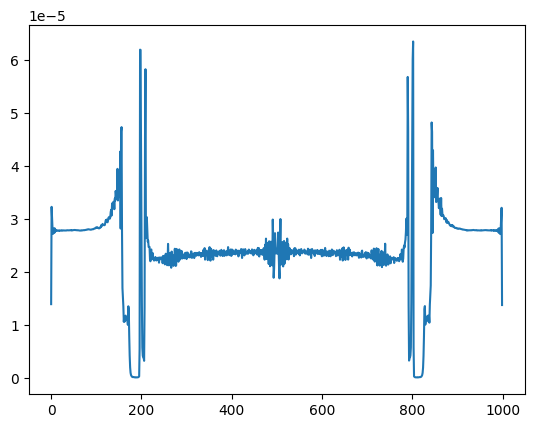

In [9]:
#double_ring_911_844_803_0d_3e-7.npy

sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_0d.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

[-4.000e-03 -3.992e-03 -3.984e-03 -3.976e-03 -3.968e-03 -3.960e-03
 -3.952e-03 -3.944e-03 -3.936e-03 -3.928e-03 -3.920e-03 -3.912e-03
 -3.904e-03 -3.896e-03 -3.888e-03 -3.880e-03 -3.872e-03 -3.864e-03
 -3.856e-03 -3.848e-03 -3.840e-03 -3.832e-03 -3.824e-03 -3.816e-03
 -3.808e-03 -3.800e-03 -3.792e-03 -3.784e-03 -3.776e-03 -3.768e-03
 -3.760e-03 -3.752e-03 -3.744e-03 -3.736e-03 -3.728e-03 -3.720e-03
 -3.712e-03 -3.704e-03 -3.696e-03 -3.688e-03 -3.680e-03 -3.672e-03
 -3.664e-03 -3.656e-03 -3.648e-03 -3.640e-03 -3.632e-03 -3.624e-03
 -3.616e-03 -3.608e-03 -3.600e-03 -3.592e-03 -3.584e-03 -3.576e-03
 -3.568e-03 -3.560e-03 -3.552e-03 -3.544e-03 -3.536e-03 -3.528e-03
 -3.520e-03 -3.512e-03 -3.504e-03 -3.496e-03 -3.488e-03 -3.480e-03
 -3.472e-03 -3.464e-03 -3.456e-03 -3.448e-03 -3.440e-03 -3.432e-03
 -3.424e-03 -3.416e-03 -3.408e-03 -3.400e-03 -3.392e-03 -3.384e-03
 -3.376e-03 -3.368e-03 -3.360e-03 -3.352e-03 -3.344e-03 -3.336e-03
 -3.328e-03 -3.320e-03 -3.312e-03 -3.304e-03 -3.296e-03 -3.288

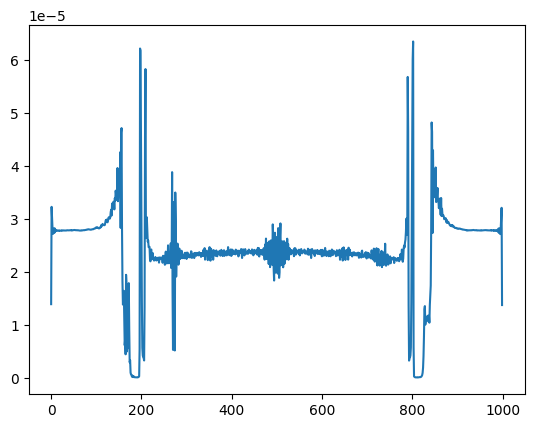

In [9]:
#double_ring_911_844_803_3d_3e-7.npy
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output_3d.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

[-4.000e-03 -3.992e-03 -3.984e-03 -3.976e-03 -3.968e-03 -3.960e-03
 -3.952e-03 -3.944e-03 -3.936e-03 -3.928e-03 -3.920e-03 -3.912e-03
 -3.904e-03 -3.896e-03 -3.888e-03 -3.880e-03 -3.872e-03 -3.864e-03
 -3.856e-03 -3.848e-03 -3.840e-03 -3.832e-03 -3.824e-03 -3.816e-03
 -3.808e-03 -3.800e-03 -3.792e-03 -3.784e-03 -3.776e-03 -3.768e-03
 -3.760e-03 -3.752e-03 -3.744e-03 -3.736e-03 -3.728e-03 -3.720e-03
 -3.712e-03 -3.704e-03 -3.696e-03 -3.688e-03 -3.680e-03 -3.672e-03
 -3.664e-03 -3.656e-03 -3.648e-03 -3.640e-03 -3.632e-03 -3.624e-03
 -3.616e-03 -3.608e-03 -3.600e-03 -3.592e-03 -3.584e-03 -3.576e-03
 -3.568e-03 -3.560e-03 -3.552e-03 -3.544e-03 -3.536e-03 -3.528e-03
 -3.520e-03 -3.512e-03 -3.504e-03 -3.496e-03 -3.488e-03 -3.480e-03
 -3.472e-03 -3.464e-03 -3.456e-03 -3.448e-03 -3.440e-03 -3.432e-03
 -3.424e-03 -3.416e-03 -3.408e-03 -3.400e-03 -3.392e-03 -3.384e-03
 -3.376e-03 -3.368e-03 -3.360e-03 -3.352e-03 -3.344e-03 -3.336e-03
 -3.328e-03 -3.320e-03 -3.312e-03 -3.304e-03 -3.296e-03 -3.288

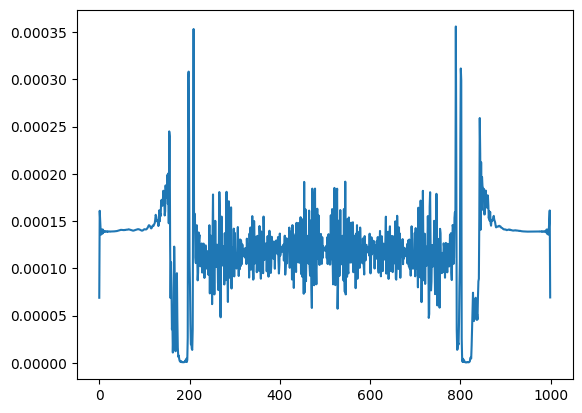

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
from contextlib import redirect_stdout
with open('output.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])
print(detector_x)

[2.84865819e-04 2.81369896e-04 2.81555345e-04 2.81390065e-04
 2.81216984e-04 2.81131535e-04 2.81243643e-04 2.81394488e-04
 2.82037712e-04 2.83181987e-04 2.85089598e-04 2.85910181e-04
 2.85673043e-04 2.86562718e-04 2.87506467e-04 2.85626971e-04
 2.84343667e-04 2.86122959e-04 2.87932111e-04 2.85813032e-04
 2.84539681e-04 2.87753355e-04 2.89447664e-04 2.97439808e-04
 2.93133839e-04 2.98861676e-04 3.16324062e-04 3.08136456e-04
 3.30154959e-04 3.52026836e-04 3.62921419e-04 3.77403077e-04
 3.52312200e-04 1.35836744e-04 1.11659487e-04 1.29988621e-04
 1.08909597e-04 9.30541937e-05 8.47106730e-06 1.43387456e-06
 6.75728757e-07 4.46892636e-06 1.75339155e-04 3.77080432e-04
 8.87146452e-05 1.76784844e-04 3.39814811e-04 2.35658546e-04
 2.28743549e-04 2.44656345e-04 2.24888659e-04 2.13066203e-04
 2.28407836e-04 2.33587241e-04 2.23110925e-04 2.31751124e-04
 2.29652374e-04 2.27727942e-04 2.06708501e-04 2.41763177e-04
 2.23709256e-04 2.61386653e-04 1.82624543e-04 2.49717850e-04
 2.22612391e-04 2.367576

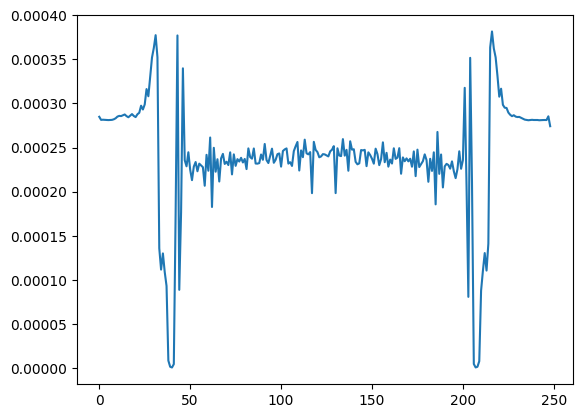

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
print(detector_x)

[1.10267698e-04 1.08864282e-04 1.09066190e-04 1.09616434e-04
 1.08116779e-04 1.09643748e-04 1.11119378e-04 1.13391121e-04
 1.13632130e-04 1.21534496e-04 1.19507342e-04 1.32059664e-04
 1.42806297e-04 1.44074511e-04 1.09674460e-04 5.17734115e-05
 4.61020354e-05 5.40949222e-05 4.93647713e-05 2.03894797e-05
 1.06198718e-06 3.91682477e-07 2.55101600e-06 1.08739041e-04
 1.40786840e-04 9.24588676e-05 8.20718124e-05 7.98249457e-05
 8.65804614e-05 8.47302799e-05 8.07641336e-05 8.09630001e-05
 8.68212883e-05 8.75417973e-05 8.36181716e-05 8.71235679e-05
 8.73930403e-05 8.65941038e-05 7.83648575e-05 9.03546679e-05
 7.89271289e-05 9.72925700e-05 8.72241799e-05 8.10021447e-05
 8.41193760e-05 9.20530147e-05 9.13781478e-05 8.41490910e-05
 8.47466436e-05 9.12320174e-05 8.58368294e-05 9.05461056e-05
 8.42828013e-05 9.13205440e-05 8.63530950e-05 8.90600568e-05
 8.95099947e-05 8.89116563e-05 9.00223313e-05 9.08474030e-05
 8.68065254e-05 9.01020903e-05 8.95799458e-05 8.89458024e-05
 8.71644734e-05 8.851943

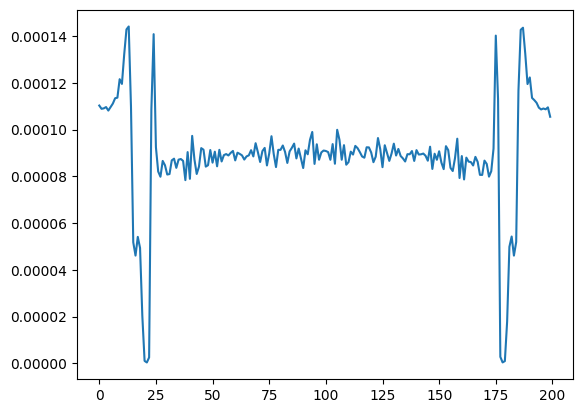

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
print(detector_x)

## History

To see the interference pattern in empty space, we can record slices throughout the simulation and then plot them. `run_single_simulation` takes an optional argument `history_dz` defining the resolution with which we record the history.

Note that the history is not necessarily recorded with a constant z-spacing. Inside gratings and samples, one slice is recorded for every step. The history also records a list of z-coordinates at which the slices were recorded, which we can use for plotting.

In [ ]:
multisim.run_single_simulation(sim_path, 1, scratch_dir, save_keypoints_path=None, history_dz=0.02)

In [ ]:
# Path to the directory for the source with index 1
source_dir = multisim.get_sub_dir(sim_path, 1)

hist_x = np.load(source_dir / "history_x.npy")
hist_z = np.load(source_dir / "history_z.npy")
hist = np.load(source_dir / "history.npy")
plt.pcolormesh(
    hist_z,
    hist_x,
    hist,
    cmap="Greys_r",
    vmin=0,
    vmax=1e-6,
    shading="nearest",
)
plt.xlabel("z (m)")
plt.ylabel("x (m)")